In [8]:
import numpy as np
import pandas as pd
import joblib
import os
import sys
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# 1. CONFIGURACIÓN DE RUTAS ABSOLUTAS
# ---------------------------------------------------------
base_path = "/home/a01795976/accelerated-drug-design/Predictor"
output_path = os.path.join(base_path, "outputs")
data_path = os.path.join(base_path, "data")
models_dir = os.path.join(output_path, "models")

print(f"🚀 Iniciando validación en: {base_path}")

# ---------------------------------------------------------
# 2. CARGA Y PREPARACIÓN DE DATOS
# ---------------------------------------------------------
xtest_path = os.path.join(output_path, 'X_test.npy')
ytest_path = os.path.join(output_path, 'y_test.npy')

try:
    print("✅ Cargando archivos de test...")
    X_test_all = np.load(xtest_path) # Este suele tener 481 columnas
    y_test = np.load(ytest_path)
    
    df_full = pd.read_csv(os.path.join(data_path, 'processed_dataset.csv'))
    # Split idéntico al entrenamiento (random_state 42)
    _, df_test_meta = train_test_split(df_full, test_size=0.2, random_state=42)
    
    print(f"✅ Datos cargados: {X_test_all.shape[0]} muestras con {X_test_all.shape[1]} features.")
except FileNotFoundError:
    print(f"❌ ERROR: No se encontró X_test.npy en {output_path}. Revisa el Notebook 02.")
    sys.exit()

# ---------------------------------------------------------
# 3. EVALUACIÓN DE MODELOS CON AJUSTE DE DIMENSIONES
# ---------------------------------------------------------
# Lista de modelos que confirmamos en tu carpeta 'outputs'
models_list = ["ridge", "rf", "mlp_sk", "xgb", "lgbm"] 
results = []
df_preds = pd.DataFrame()
df_preds["seq"] = df_test_meta["seq"].values
df_preds["PTM_real"] = y_test[:, 0]
df_preds["IPTM_real"] = y_test[:, 1]

print("\n🔍 Analizando modelos guardados...")

for name in models_list:
    # Probamos con el nombre que vimos en tu 'ls' (model_XXX.pkl)
    filename = f"model_{name}.pkl"
    path = os.path.join(output_path, filename)
    if not os.path.exists(path):
        path = os.path.join(models_dir, filename)
            
    if os.path.exists(path):
        print(f"\n📦 Cargando: {filename}")
        model = joblib.load(path)
        
        # --- LÓGICA DE CORRECCIÓN DE DIMENSIONES (481 vs 480) ---
        try:
            # Preguntamos al modelo cuántas features espera
            n_expected = model.n_features_in_
            n_actual = X_test_all.shape[1]
            
            if n_actual > n_expected:
                # Si tenemos 481 pero el modelo espera 480 (ESM-2 puro), recortamos el score
                X_input = X_test_all[:, :n_expected]
                print(f"   ⚠️ Ajuste: El modelo espera {n_expected}. Usando solo embeddings ESM-2.")
            else:
                X_input = X_test_all
                print(f"   ✅ El modelo usa las {n_expected} features completas.")
            
            # Predicción
            preds = model.predict(X_input)
            
            # Validar que la predicción tenga 2 columnas (PTM, IPTM)
            if preds.ndim == 1 or preds.shape[1] < 2:
                print(f"   ❌ {name}: Predicción incompleta (solo 1 columna). Saltando.")
                continue

            # Cálculo de métricas para reporte
            r2_ptm = r2_score(y_test[:, 0], preds[:, 0])
            r2_iptm = r2_score(y_test[:, 1], preds[:, 1])
            
            results.append({
                "model": name,
                "R2_PTM": r2_ptm,
                "R2_IPTM": r2_iptm,
                "RMSE_PTM": np.sqrt(mean_squared_error(y_test[:, 0], preds[:, 0])),
                "RMSE_IPTM": np.sqrt(mean_squared_error(y_test[:, 1], preds[:, 1]))
            })
            
            # Guardamos predicciones para el Ensemble
            df_preds[f"{name}_PTM"] = preds[:, 0]
            df_preds[f"{name}_IPTM"] = preds[:, 1]
            
        except Exception as e:
            print(f"   ❌ Error evaluando {name}: {e}")
    else:
        print(f"  ⚠️ {name.upper()}: Archivo no encontrado. Saltando.")

# ---------------------------------------------------------
# 4. ENSEMBLE Y GENERACIÓN DE ARCHIVOS FINALES
# ---------------------------------------------------------
if results:
    # Seleccionamos columnas de predicción (excluyendo las reales)
    ptm_cols = [c for c in df_preds.columns if "_PTM" in c and "real" not in c]
    iptm_cols = [c for c in df_preds.columns if "_IPTM" in c and "real" not in c]
    
    # Creamos el promedio (Ensemble)
    df_preds["Ensemble_PTM"] = df_preds[ptm_cols].mean(axis=1)
    df_preds["Ensemble_IPTM"] = df_preds[iptm_cols].mean(axis=1)

    # Guardar métricas para tu tabla de comparación
    df_metrics = pd.DataFrame(results)
    df_metrics.to_csv(os.path.join(output_path, 'model_metrics_final.csv'), index=False)
    
    # Guardar predicciones CRUCIALES para el script 04
    df_preds.to_csv(os.path.join(output_path, 'predictions_all_models.csv'), index=False)

    print("\n" + "="*50)
    print("🏆 REPORTE DE EVALUACIÓN FINALIZADO")
    print("="*50)
    print(df_metrics[["model", "R2_PTM", "R2_IPTM"]].sort_values(by="R2_PTM", ascending=False))
    print(f"\n📂 Archivo generado para filtrado: {output_path}/predictions_all_models.csv")
    print("👉 PRÓXIMO PASO: Ejecuta 'python evaluation/04_filter_candidates.py' en tu terminal.")
else:
    print("\n❌ No se pudo evaluar ningún modelo correctamente.")

🚀 Iniciando validación en: /home/a01795976/accelerated-drug-design/Predictor
✅ Cargando archivos de test...
✅ Datos cargados: 9004 muestras con 481 features.

🔍 Analizando modelos guardados...

📦 Cargando: model_ridge.pkl
   ⚠️ Ajuste: El modelo espera 480. Usando solo embeddings ESM-2.

📦 Cargando: model_rf.pkl
   ⚠️ Ajuste: El modelo espera 480. Usando solo embeddings ESM-2.

📦 Cargando: model_mlp_sk.pkl
   ⚠️ Ajuste: El modelo espera 480. Usando solo embeddings ESM-2.

📦 Cargando: model_xgb.pkl


[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  74 out of 100 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.1s finished


   ⚠️ Ajuste: El modelo espera 480. Usando solo embeddings ESM-2.

📦 Cargando: model_lgbm.pkl
   ⚠️ Ajuste: El modelo espera 480. Usando solo embeddings ESM-2.


/home/a01795976/miniconda3/envs/validador/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/a01795976/miniconda3/envs/validador/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



🏆 REPORTE DE EVALUACIÓN FINALIZADO
    model    R2_PTM   R2_IPTM
3     xgb  0.836299  0.878105
1      rf  0.827654  0.874998
4    lgbm  0.796278  0.848856
0   ridge  0.670595  0.750838
2  mlp_sk  0.483439  0.679921

📂 Archivo generado para filtrado: /home/a01795976/accelerated-drug-design/Predictor/outputs/predictions_all_models.csv
👉 PRÓXIMO PASO: Ejecuta 'python evaluation/04_filter_candidates.py' en tu terminal.


In [9]:
import pandas as pd

df = pd.read_csv("../outputs/predictions_all_models.csv")
df.head()

,seq,PTM_real,IPTM_real,ridge_PTM,ridge_IPTM,rf_PTM,rf_IPTM,mlp_sk_PTM,mlp_sk_IPTM,xgb_PTM,xgb_IPTM,lgbm_PTM,lgbm_IPTM,Ensemble_PTM,Ensemble_IPTM
0,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...,0.706,0.654,0.694910,0.590487,0.702725,0.657386,0.725832,0.729678,0.706632,0.657220,0.705754,0.658004,0.707171,0.658555
1,FTVTVPKDLYVVEYGSNMTIECKFPVEKQLDLAALIVYWEMEDKNI...,0.722,0.135,0.734124,0.199800,0.727578,0.175128,0.737276,0.192921,0.728475,0.181741,0.734620,0.207021,0.732415,0.191322
2,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...,0.695,0.621,0.702927,0.666278,0.694739,0.622203,0.728383,0.730872,0.695523,0.623905,0.696878,0.628727,0.703690,0.654397
3,FTVTVPKDLYVVEYGSNMTIECKFPVEKQLDLAALIVYWEMEDKNI...,0.730,0.177,0.723019,0.166380,0.729505,0.190445,0.735635,0.187726,0.733323,0.174176,0.731611,0.185138,0.730619,0.180773
4,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...,0.704,0.662,0.697183,0.622404,0.706601,0.667358,0.722570,0.730254,0.701158,0.675520,0.704064,0.662497,0.706315,0.671606


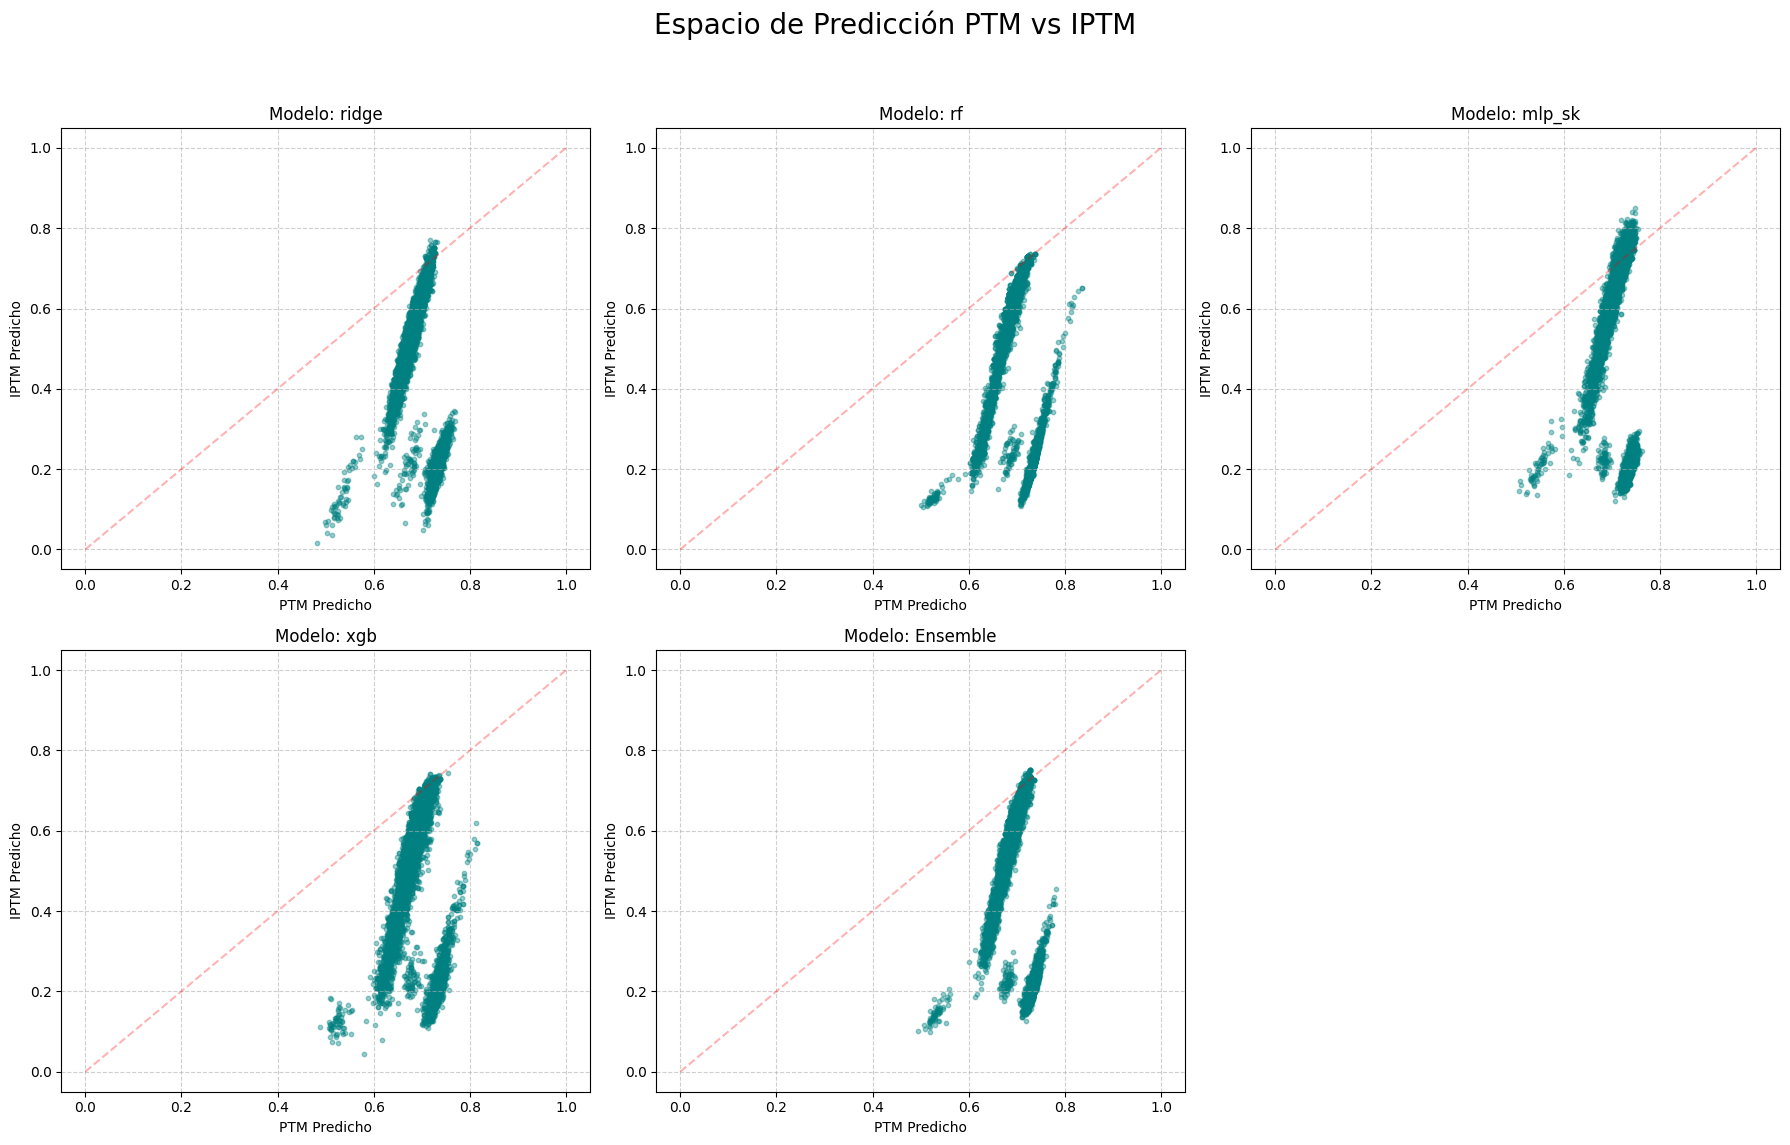

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Configuración de rutas (usando rutas relativas o absolutas según tu caso)
# Si te da error con ../, cámbialo por la ruta absoluta: /home/a01795976/accelerated-drug-design/Predictor/outputs/
output_path = "../outputs"
pred_file = os.path.join(output_path, "predictions_all_models.csv")
ytest_file = os.path.join(output_path, "y_test.npy")

# Cargar datos
df_pred = pd.read_csv(pred_file)
y_test = np.load(ytest_file)

# Asegurar que los valores reales estén (usamos .iloc por si hay discrepancia de tamaños)
df_pred["PTM_real"] = y_test[:len(df_pred), 0]
df_pred["IPTM_real"] = y_test[:len(df_pred), 1]

# --- CAMBIO AQUÍ: Nombres exactos de las columnas en el CSV ---
# Cambiamos 'mlp' por 'mlp_sk' y agregamos 'Ensemble'
models_to_plot = ["ridge", "rf", "mlp_sk", "xgb", "Ensemble"]

plt.figure(figsize=(18, 12))

for i, model in enumerate(models_to_plot, 1):
    # Ajustamos el grid para 5 modelos (2 filas, 3 columnas)
    plt.subplot(2, 3, i)
    
    # Intentar obtener las columnas, si no existen saltar
    try:
        ptm = df_pred[f"{model}_PTM"]
        iptm = df_pred[f"{model}_IPTM"]
        
        plt.scatter(ptm, iptm, alpha=0.4, s=10, c='teal')
        plt.xlabel("PTM Predicho")
        plt.ylabel("IPTM Predicho")
        plt.title(f"Modelo: {model}")
        plt.grid(True, linestyle='--', alpha=0.6)
        
        # Dibujar una línea diagonal de referencia si quieres ver correlación
        plt.plot([0, 1], [0, 1], color='red', linestyle='--', alpha=0.3)
        
    except KeyError:
        plt.title(f"Modelo {model} no encontrado")

plt.suptitle("Espacio de Predicción PTM vs IPTM", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

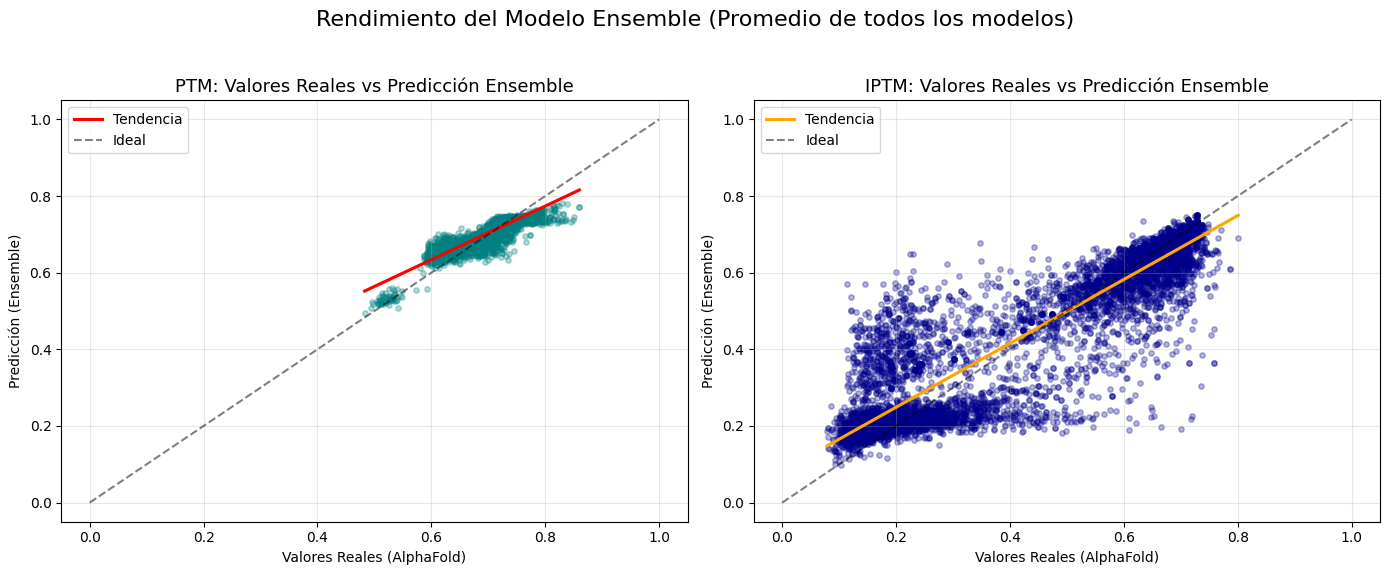

In [13]:
# --- GRÁFICO 2: Análisis Profundo del Ensemble (Promedio de modelos) ---
# Comprobamos que las columnas existan antes de graficar
if "Ensemble_PTM" in df_pred.columns and "PTM_real" in df_pred.columns:
    plt.figure(figsize=(14, 6))

    # Subplot A: Predicho vs Real (PTM)
    plt.subplot(1, 2, 1)
    # Regplot dibuja la línea de regresión ideal en rojo
    sns.regplot(x=df_pred["PTM_real"], y=df_pred["Ensemble_PTM"], 
                scatter_kws={'alpha':0.3, 's':15, 'color':'teal'}, 
                line_kws={'color':'red', 'label':'Tendencia'})
    
    # Dibujar la diagonal perfecta (donde Real == Predicho)
    plt.plot([0, 1], [0, 1], color='black', linestyle='--', alpha=0.5, label='Ideal')
    
    plt.title("PTM: Valores Reales vs Predicción Ensemble", fontsize=13)
    plt.xlabel("Valores Reales (AlphaFold)")
    plt.ylabel("Predicción (Ensemble)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subplot B: Predicho vs Real (IPTM)
    plt.subplot(1, 2, 2)
    sns.regplot(x=df_pred["IPTM_real"], y=df_pred["Ensemble_IPTM"], 
                scatter_kws={'alpha':0.3, 's':15, 'color':'darkblue'}, 
                line_kws={'color':'orange', 'label':'Tendencia'})
    
    plt.plot([0, 1], [0, 1], color='black', linestyle='--', alpha=0.5, label='Ideal')
    
    plt.title("IPTM: Valores Reales vs Predicción Ensemble", fontsize=13)
    plt.xlabel("Valores Reales (AlphaFold)")
    plt.ylabel("Predicción (Ensemble)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.suptitle("Rendimiento del Modelo Ensemble (Promedio de todos los modelos)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("❌ Error: No se encontraron las columnas 'Ensemble_PTM' o 'PTM_real'.")
    print("Columnas actuales:", df_pred.columns.tolist())

📊 Generando gráficos de regresión...


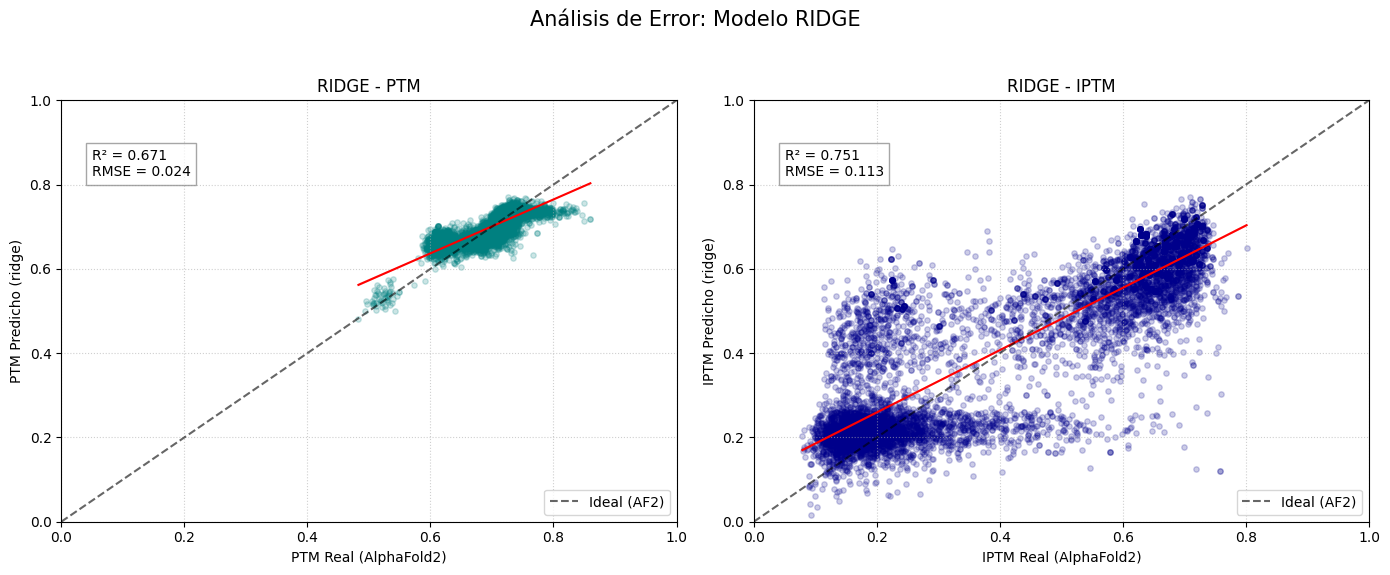

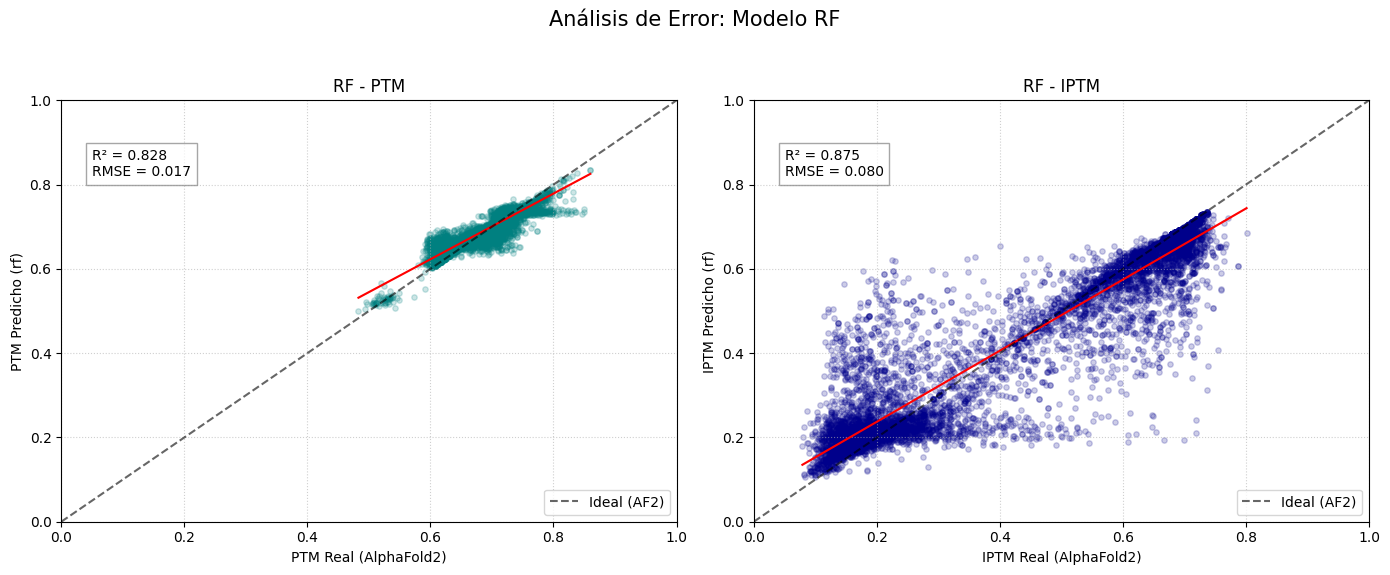

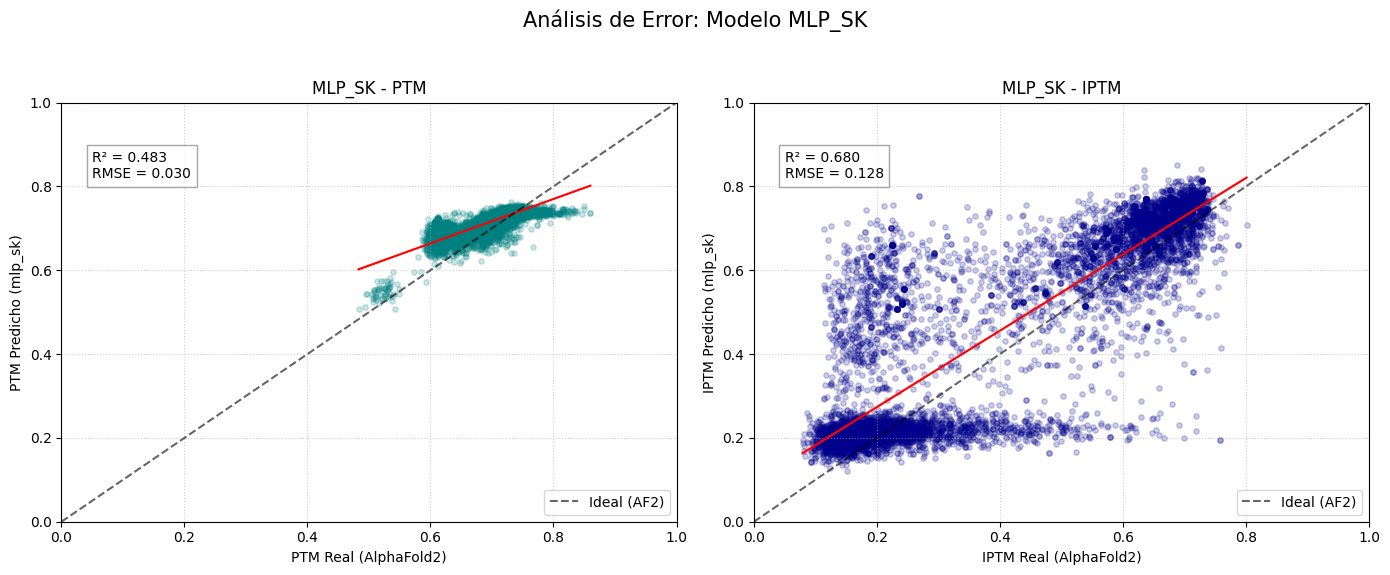

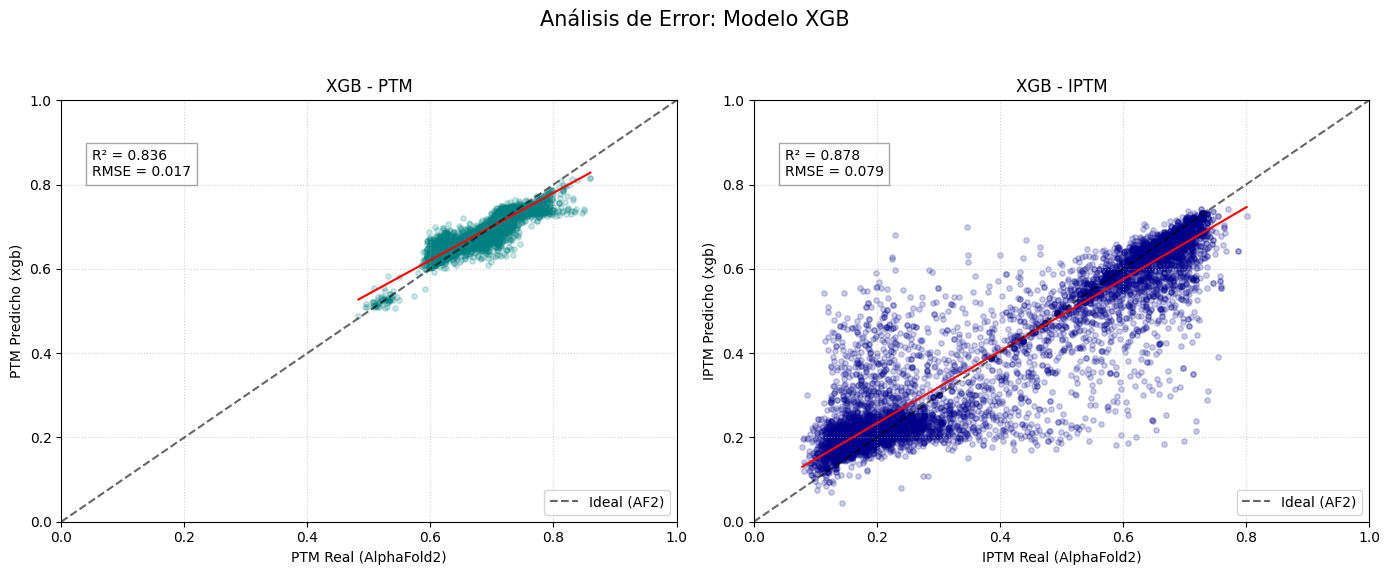

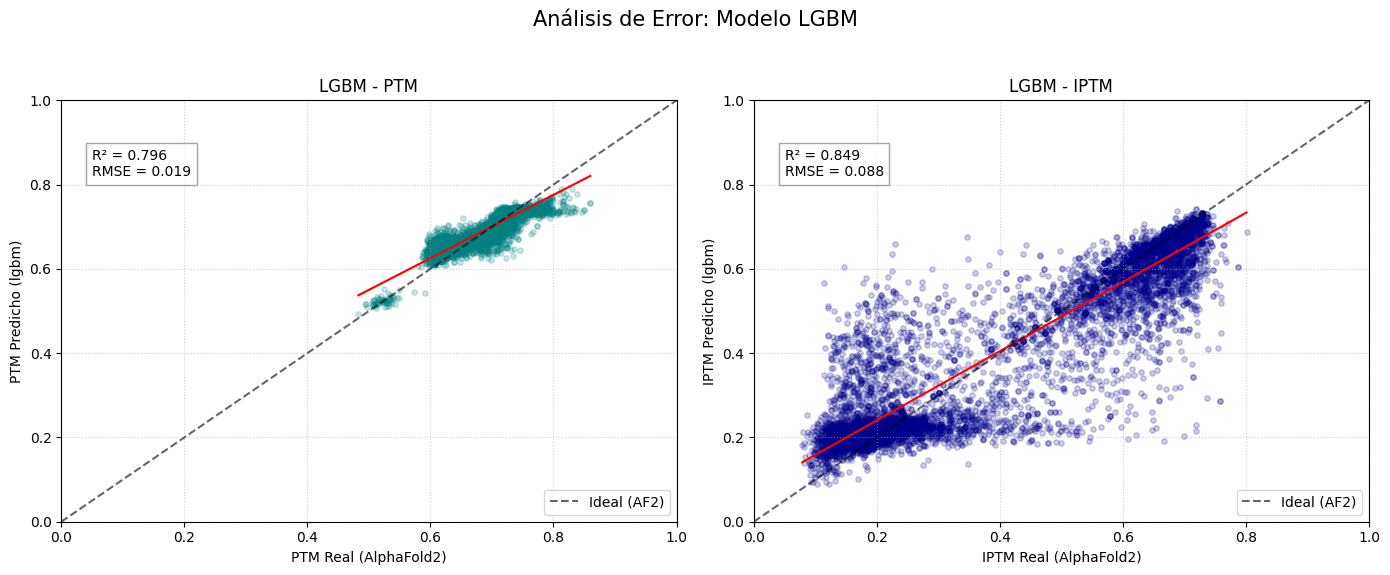

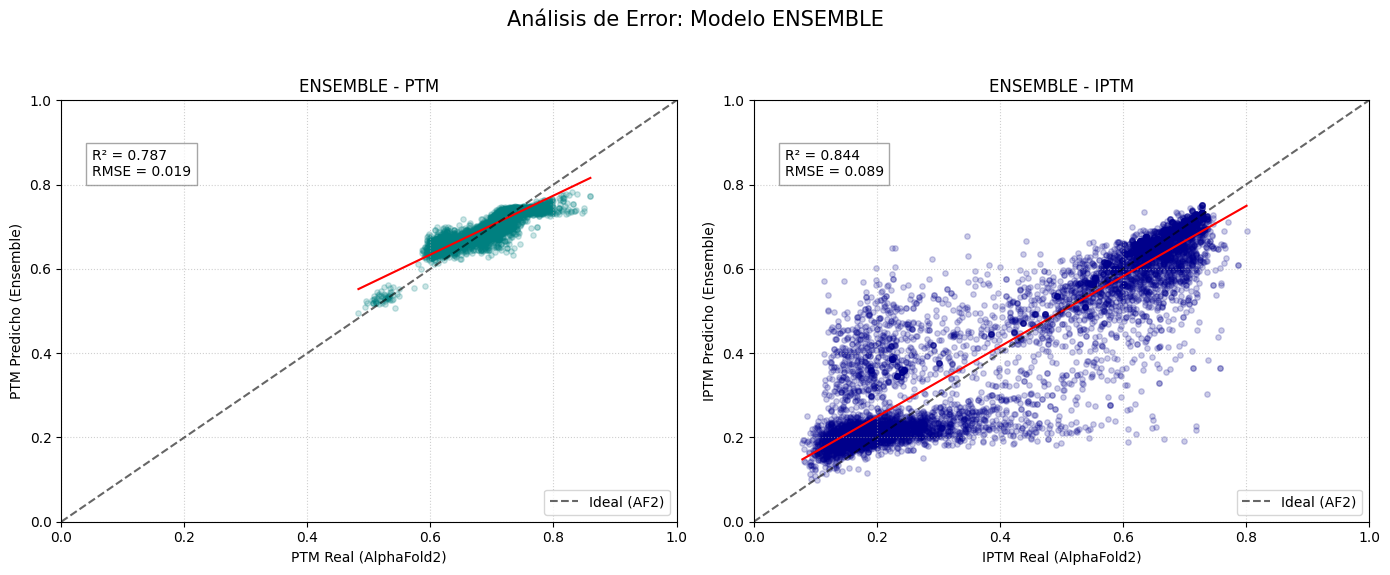

In [15]:
# --- GRÁFICO 3: Regresión Real vs Predicho (Por target y modelo) ---

# 1. Definimos los nombres EXACTOS que tienen tus columnas en df_pred
# Ajustado: 'mlp' -> 'mlp_sk' y añadimos 'Ensemble'
models_to_plot = ["ridge", "rf", "mlp_sk", "xgb", "lgbm", "Ensemble"]
targets = ["PTM", "IPTM"]

print("📊 Generando gráficos de regresión...")

for model in models_to_plot:
    # Verificamos si al menos una columna de este modelo existe en el DataFrame
    if f"{model}_PTM" not in df_pred.columns:
        continue
        
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for j, target in enumerate(targets):
        pred_col = f"{model}_{target}"
        real_col = f"{target}_real"
        
        # Extraer datos evitando NaNs
        y_true = df_pred[real_col]
        y_pred = df_pred[pred_col]
        
        # Cálculo de métricas para el cuadro de texto
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        
        # Gráfico de regresión
        sns.regplot(x=y_true, y=y_pred, ax=axes[j], 
                    scatter_kws={"alpha": 0.2, "s": 15, "color": "teal" if target == "PTM" else "darkblue"}, 
                    line_kws={"color": "red", "lw": 1.5})
        
        # Línea ideal (identidad)
        axes[j].plot([0, 1], [0, 1], 'k--', alpha=0.6, label="Ideal (AF2)")
        
        # Formato
        axes[j].set_xlim(0, 1)
        axes[j].set_ylim(0, 1)
        axes[j].set_xlabel(f"{target} Real (AlphaFold2)")
        axes[j].set_ylabel(f"{target} Predicho ({model})")
        axes[j].set_title(f"{model.upper()} - {target}")
        
        # Cuadro de métricas
        stats_text = f"R² = {r2:.3f}\nRMSE = {rmse:.3f}"
        axes[j].text(0.05, 0.82, stats_text, transform=axes[j].transAxes, 
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))
        
        axes[j].legend(loc="lower right")
        axes[j].grid(True, linestyle=':', alpha=0.6)
    
    plt.suptitle(f"Análisis de Error: Modelo {model.upper()}", fontsize=15)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

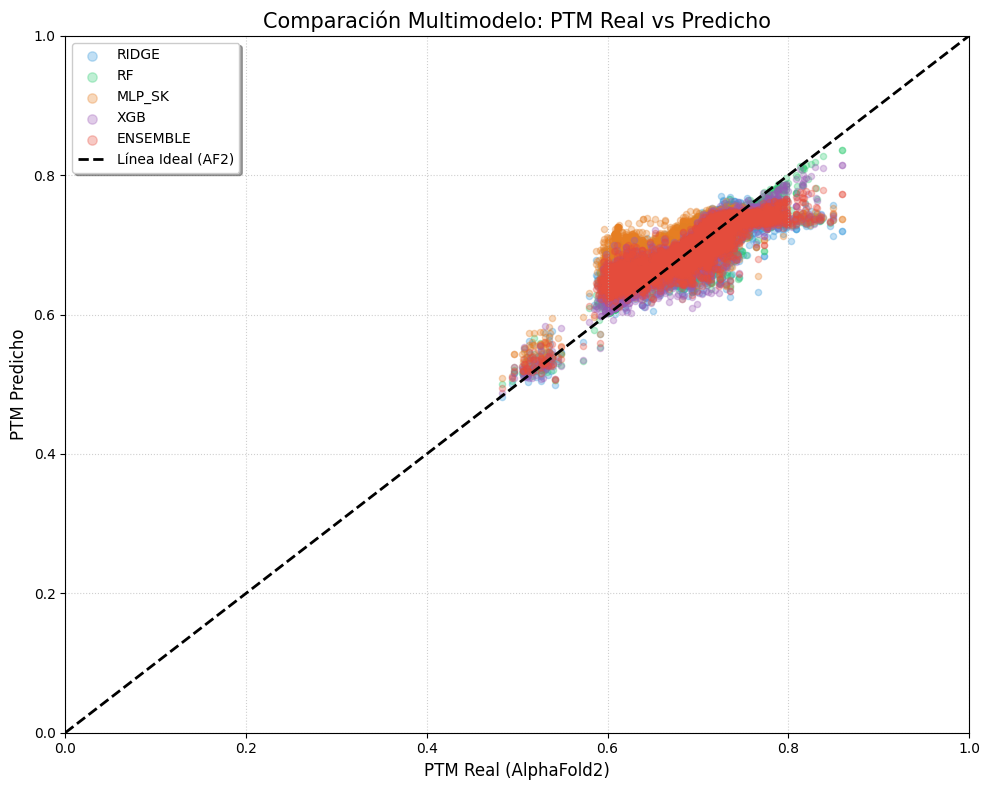

In [17]:
# --- GRÁFICO 4: Comparación de todos los modelos (PTM real vs predicho) ---

# 1. Redefinimos modelos y colores con los nombres EXACTOS del CSV
models_to_compare = ["ridge", "rf", "mlp_sk", "xgb", "Ensemble"]
colors_map = {
    "ridge": "#3498db",     # Azul
    "rf": "#2ecc71",        # Verde
    "mlp_sk": "#e67e22",    # Naranja
    "xgb": "#9b59b6",       # Morado
    "Ensemble": "#e74c3c"   # Rojo
}

plt.figure(figsize=(10, 8))

for model in models_to_compare:
    # Verificamos si la columna existe antes de intentar graficar
    col_name = f"{model}_PTM"
    
    if col_name in df_pred.columns:
        plt.scatter(
            df_pred["PTM_real"],
            df_pred[col_name],
            alpha=0.3,
            color=colors_map.get(model, "gray"),
            label=model.upper(),
            s=20
        )
    else:
        print(f"⚠️ Columna {col_name} no encontrada, saltando...")

# Línea de referencia ideal
plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=2, label="Línea Ideal (AF2)")

# Configuración estética
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("PTM Real (AlphaFold2)", fontsize=12)
plt.ylabel("PTM Predicho", fontsize=12)
plt.title("Comparación Multimodelo: PTM Real vs Predicho", fontsize=15)
plt.legend(markerscale=1.5, loc="upper left", frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()